<a href="https://colab.research.google.com/github/keivernunez/dataminingavanzado_austral/blob/main/Clase3_Note1_de_3_Redes_Neuronales_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptrón Multicapa (MLP) en Python

Este notebook explora la implementación de un Perceptrón Multicapa (MLP), un tipo fundamental de red neuronal artificial, para resolver un problema de clasificación binaria. Se abordará el mismo problema desde tres perspectivas:

1.  **Construcción Manual con NumPy**: Para entender los mecanismos internos como *feedforward* y *backpropagation*.
2.  **Implementación con Scikit-learn**: Un enfoque de alto nivel, práctico y eficiente para modelos de machine learning.
3.  **Implementación con Keras (TensorFlow)**: Utilizando una librería especializada en *deep learning* que ofrece mayor flexibilidad para arquitecturas complejas.

![MLP Diagram](https://i.ytimg.com/vi/Fz4Uo8_uUfg/hqdefault.jpg)

## Componentes de un Perceptrón Multicapa

Un MLP se compone de varias capas de neuronas interconectadas:

* **Capa de Entrada**: Recibe los datos iniciales. El número de neuronas corresponde al número de características (variables) en el dataset.
* **Capas Ocultas**: Son las capas intermedias donde ocurre el procesamiento principal. La red aprende a detectar características complejas y no lineales en estas capas.
    * Una red con una sola capa oculta se denomina *shallow neural network* (red neuronal superficial).
    * Una red con múltiples capas ocultas se considera una *deep neural network* (red neuronal profunda), siendo la base del *deep learning*.
* **Capa de Salida**: Produce el resultado final. El número de neuronas depende del tipo de problema (por ejemplo, una para clasificación binaria, o múltiples para clasificación multiclase).

Para construir un MLP, debemos definir:

* **Arquitectura de la Red**: El número de capas ocultas y la cantidad de neuronas en cada una.
* **Función de Activación**: Determina la salida de una neurona. Introduce no linealidad, permitiendo a la red aprender relaciones complejas. Ejemplos comunes son **Sigmoide** y **ReLu**:
* **Sigmoide**: $\sigma(x) = \dfrac{1}{1 + e^{-x}}$. Comprime los valores a un rango entre 0 y 1. Es útil en la capa de salida para problemas de clasificación binaria.
  * **ReLu** (Rectified Linear Unit): $f(x) = \max(0,x)$. Es computacionalmente eficiente y la más utilizada en las capas ocultas.
  * **Función de Pérdida (*Loss Function*)**: Mide qué tan bueno es el modelo al comparar la predicción con el valor real. El objetivo del entrenamiento es minimizar esta función.
* **Optimizador**: El algoritmo que actualiza los pesos de la red para minimizar la función de pérdida (ej. Descenso de Gradiente, Adam).

## 1. Preparación de Datos
Primero, cargaremos las librerías necesarias y prepararemos el dataset del Titanic. La preparación incluye la carga de datos, la separación en conjuntos de entrenamiento y prueba, y el **escalado de características**.

**¿Por qué es importante escalar los datos?**
Las redes neuronales son sensibles a la escala de las características de entrada. Si una característica tiene un rango de valores mucho mayor que otras (ej. Edad vs. Clase de Pasajero), puede dominar el proceso de aprendizaje. El `StandardScaler` transforma los datos para que tengan una media de 0 y una desviación estándar de 1, asegurando que todas las características contribuyan de manera equitativa al entrenamiento.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Montar Google Drive para acceder a los archivos
drive.mount("/content/drive")
contentFolder = "/content/drive/MyDrive/Austral - Data Mining"
if not os.path.exists(contentFolder):
    os.mkdir(contentFolder)

# Cargar el dataset preprocesado del Titanic
file_path = f"{contentFolder}/titanicPreprocesada.txt"
data = pd.read_csv(file_path, sep=";")

# Separar características (X) y variable objetivo (y)
X = data.drop(columns=["index", "Survived"])
y = data.Survived

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Usar el mismo scaler ajustado en el entrenamiento

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Mounted at /content/drive
Dimensiones de X_train: (596, 9)
Dimensiones de X_test: (295, 9)


---
## 2. Modelo Manual con NumPy
Construir una red neuronal desde cero es una excelente manera de comprender su funcionamiento interno. Implementaremos el ciclo completo de *feedforward* (propagación hacia adelante), cálculo del error y *backpropagation* (retropropagación) con descenso de gradiente.

In [ ]:
# Definición de las funciones de activación y sus derivadas
def sigmoid_act(x, der=False):
    """Función de activación Sigmoide y su derivada."""
    if der:
        return sigmoid_act(x) * (1 - sigmoid_act(x))
    return 1 / (1 + np.exp(-x))

def relu_act(x, der=False):
    """Función de activación ReLU y su derivada."""
    if der:
        return np.heaviside(x, 1)
    return np.maximum(0, x)

Epoch 0, Loss: 0.249089
Epoch 10, Loss: 0.239049
Epoch 20, Loss: 0.236316
Epoch 30, Loss: 0.235072
Epoch 40, Loss: 0.233742


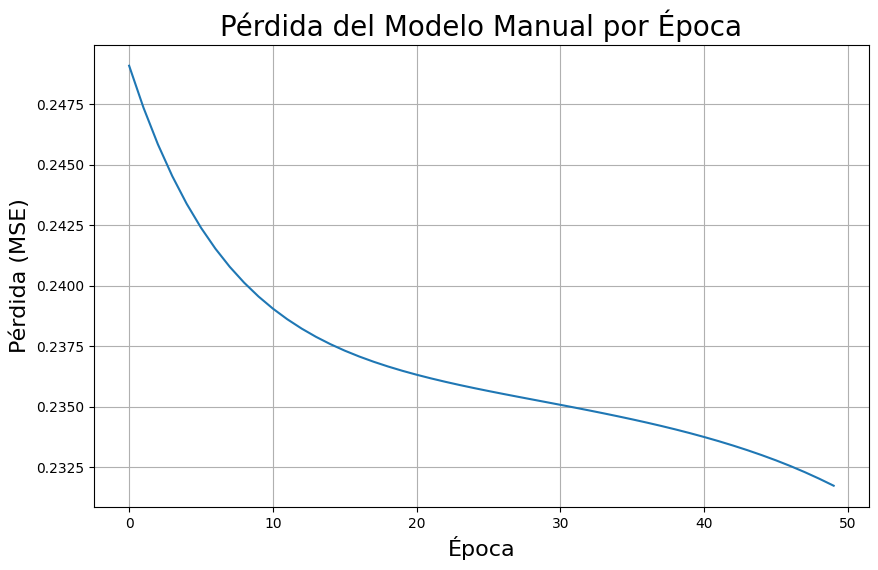

In [ ]:
def train_manual_ann(X_train, y_train, p, q, eta, epochs):
    """Entrena una red neuronal de 2 capas ocultas usando NumPy."""
    # Inicialización aleatoria de pesos y sesgos
    n_features = X_train.shape[1]
    w1 = np.random.randn(p, n_features) * 0.1
    b1 = np.zeros(p)
    w2 = np.random.randn(q, p) * 0.1
    b2 = np.zeros(q)
    wOut = np.random.randn(q) * 0.1
    bOut = np.zeros(1)

    loss_history = []

    # Bucle de entrenamiento por épocas
    for epoch in range(epochs):
        total_loss = 0
        # Bucle sobre cada muestra de entrenamiento
        for x, y_true in zip(X_train, y_train):
            # 1. Feedforward
            z1 = relu_act(np.dot(w1, x) + b1)
            z2 = relu_act(np.dot(w2, z1) + b2)
            y_pred = sigmoid_act(np.dot(wOut, z2) + bOut)

            # 2. Cálculo de la pérdida (Error Cuadrático Medio)
            loss = (y_pred - y_true)**2
            total_loss += loss

            # 3. Backpropagation
            # Derivada del error respecto a la predicción
            delta_Out = 2 * (y_pred - y_true) * sigmoid_act(y_pred, der=True)

            # Errores de las capas ocultas
            delta_2 = delta_Out * wOut * relu_act(z2, der=True)
            delta_1 = np.dot(delta_2, w2) * relu_act(z1, der=True)

            # 4. Actualización de pesos (Descenso de Gradiente)
            wOut -= eta * delta_Out * z2
            bOut -= eta * delta_Out

            w2 -= eta * np.outer(delta_2, z1)
            b2 -= eta * delta_2

            w1 -= eta * np.outer(delta_1, x)
            b1 -= eta * delta_1

        # Guardar la pérdida promedio de la época
        avg_loss = total_loss / len(X_train)
        loss_history.append(avg_loss)
        if (epoch % 10 == 0):
            print(f"Epoch {epoch}, Loss: {avg_loss[0]:.6f}")

    # Devolver los pesos entrenados y el historial de pérdida
    weights = {'w1': w1, 'b1': b1, 'w2': w2, 'b2': b2, 'wOut': wOut, 'bOut': bOut}
    return weights, loss_history

# Hiperparámetros del modelo manual
p = 8 # Neuronas en la primera capa oculta
q = 4 # Neuronas en la segunda capa oculta
eta = 0.001 # Tasa de aprendizaje
epochs = 50 # Número de épocas

# Entrenar el modelo
manual_weights, manual_loss = train_manual_ann(X_train, y_train.values, p, q, eta, epochs)

# Graficar la pérdida durante el entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(manual_loss)
plt.title('Pérdida del Modelo Manual por Época', fontsize=20)
plt.xlabel('Época', fontsize=16)
plt.ylabel('Pérdida (MSE)', fontsize=16)
plt.grid(True)
plt.show()

Accuracy del modelo manual: 0.6136


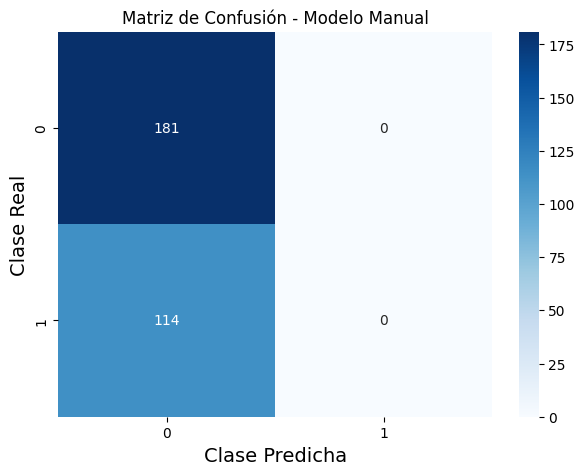

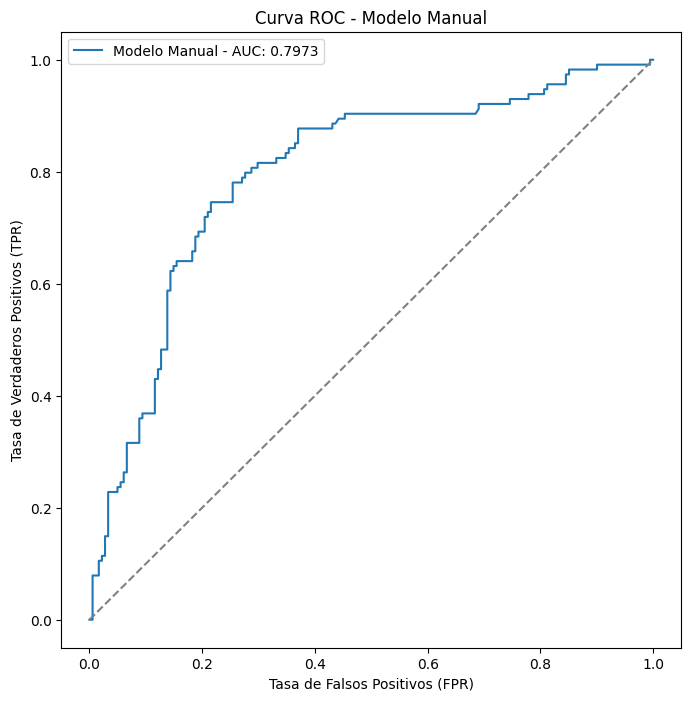

In [ ]:
def predict_manual_ann(X, weights, proba=False):
    """Realiza predicciones usando los pesos entrenados del modelo manual."""
    # Extraer pesos
    w1, b1, w2, b2, wOut, bOut = weights.values()

    predictions = []
    for x in X:
        # Feedforward
        z1 = relu_act(np.dot(w1, x) + b1)
        z2 = relu_act(np.dot(w2, z1) + b2)
        y = sigmoid_act(np.dot(wOut, z2) + bOut)
        predictions.append(y[0])

    if proba:
        return np.array(predictions)

    # Clasificación binaria con umbral de 0.5
    return (np.array(predictions) > 0.5).astype(int)

# Realizar predicciones en el conjunto de prueba
y_pred_manual = predict_manual_ann(X_test, manual_weights)
y_proba_manual = predict_manual_ann(X_test, manual_weights, proba=True)

# Evaluar el modelo manual
print(f"Accuracy del modelo manual: {accuracy_score(y_test, y_pred_manual):.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_manual)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.title('Matriz de Confusión - Modelo Manual')
plt.xlabel('Clase Predicha', fontsize=14)
plt.ylabel('Clase Real', fontsize=14)
plt.show()

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_proba_manual)
auc = roc_auc_score(y_test, y_proba_manual)
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label=f'Modelo Manual - AUC: {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curva ROC - Modelo Manual')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend()
plt.show()

---
## 3. Modelo con Scikit-learn
Ahora, utilizaremos `MLPClassifier` de Scikit-learn. Esta es una implementación optimizada y fácil de usar que abstrae la complejidad del entrenamiento. Es ideal para aplicaciones rápidas y como punto de referencia.

Accuracy del modelo Scikit-learn: 0.8102


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


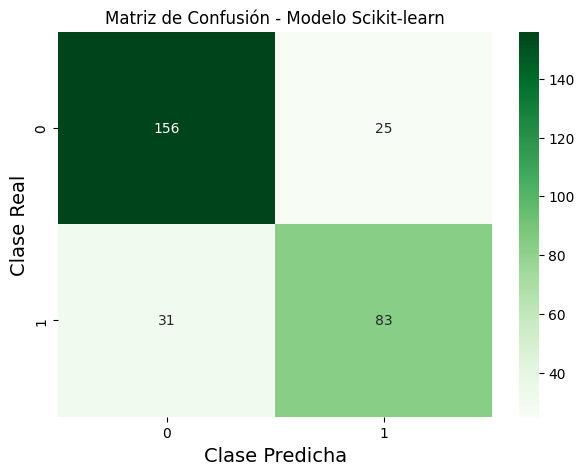

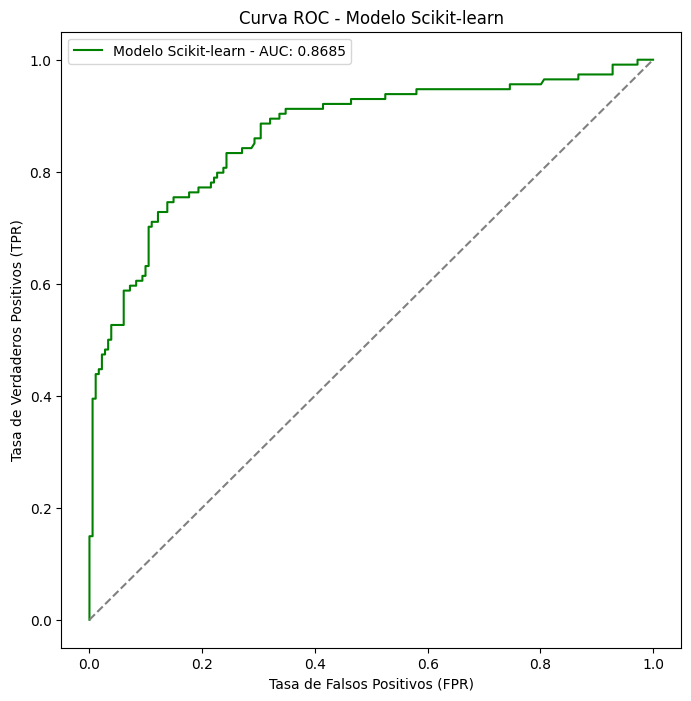

In [ ]:
from sklearn.neural_network import MLPClassifier

# Inicializar y entrenar el clasificador MLP
# hidden_layer_sizes: Define la arquitectura (dos capas ocultas con 16 y 12 neuronas)
# max_iter: Número máximo de épocas
# activation: Función de activación para las capas ocultas
# solver: Optimizador ('adam' es robusto y funciona bien en la mayoría de los casos)
clf_sklearn = MLPClassifier(hidden_layer_sizes=(16, 12),
                            max_iter=300,
                            activation='relu',
                            solver='adam',
                            random_state=1)

clf_sklearn.fit(X_train, y_train)

# Realizar predicciones
y_pred_sklearn = clf_sklearn.predict(X_test)
y_proba_sklearn = clf_sklearn.predict_proba(X_test)[:, 1]

# Evaluar el modelo de Scikit-learn
print(f"Accuracy del modelo Scikit-learn: {accuracy_score(y_test, y_pred_sklearn):.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_sklearn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens')
plt.title('Matriz de Confusión - Modelo Scikit-learn')
plt.xlabel('Clase Predicha', fontsize=14)
plt.ylabel('Clase Real', fontsize=14)
plt.show()

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_proba_sklearn)
auc = roc_auc_score(y_test, y_proba_sklearn)
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='green', label=f'Modelo Scikit-learn - AUC: {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curva ROC - Modelo Scikit-learn')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend()
plt.show()

---
## 4. Modelo con Keras / TensorFlow
Keras es una API de alto nivel para construir y entrenar modelos de deep learning. Ofrece una gran flexibilidad para crear arquitecturas complejas, monitorear el entrenamiento y utilizar aceleración por hardware (GPU/TPU). Es el estándar de la industria para el desarrollo de redes neuronales.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

# Construcción de la red neuronal con la API Sequential de Keras
model_keras = Sequential()
# Capa de entrada y primera capa oculta (16 neuronas, activación ReLU)
# input_dim debe coincidir con el número de características
model_keras.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
# Segunda capa oculta (12 neuronas, activación ReLU)
model_keras.add(Dense(12, activation='relu'))
# Capa de salida (1 neurona, activación Sigmoide para clasificación binaria)
model_keras.add(Dense(1, activation='sigmoid'))

# Compilar el modelo
# loss: 'binary_crossentropy' es la función de pérdida estándar para clasificación binaria
# optimizer: 'adam' es un optimizador eficiente
# metrics: 'AUC' (Area Under Curve) es una excelente métrica para clasificación
model_keras.compile(loss='binary_crossentropy', optimizer='adam', metrics=['AUC'])

# Imprimir un resumen de la arquitectura del modelo
model_keras.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 377 (1.47 KB)

 Trainable params: 377 (1.47 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar el modelo
# validation_data permite monitorear el rendimiento en el conjunto de prueba durante el entrenamiento
history = model_keras.fit(X_train, y_train,
                          validation_data=(X_test, y_test),
                          epochs=100,
                          verbose=0) # verbose=0 para un output más limpio

# Realizar predicciones
y_proba_keras = model_keras.predict(X_test).ravel()
y_pred_keras = (y_proba_keras > 0.5).astype(int)

# Evaluar el modelo de Keras
print(f"Accuracy del modelo Keras: {accuracy_score(y_test, y_pred_keras):.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy del modelo Keras: 0.8102


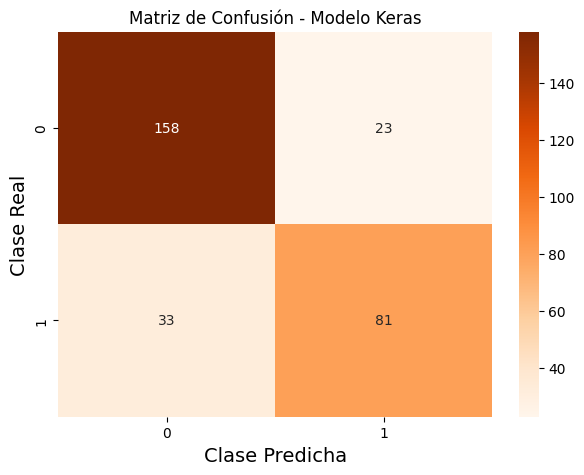

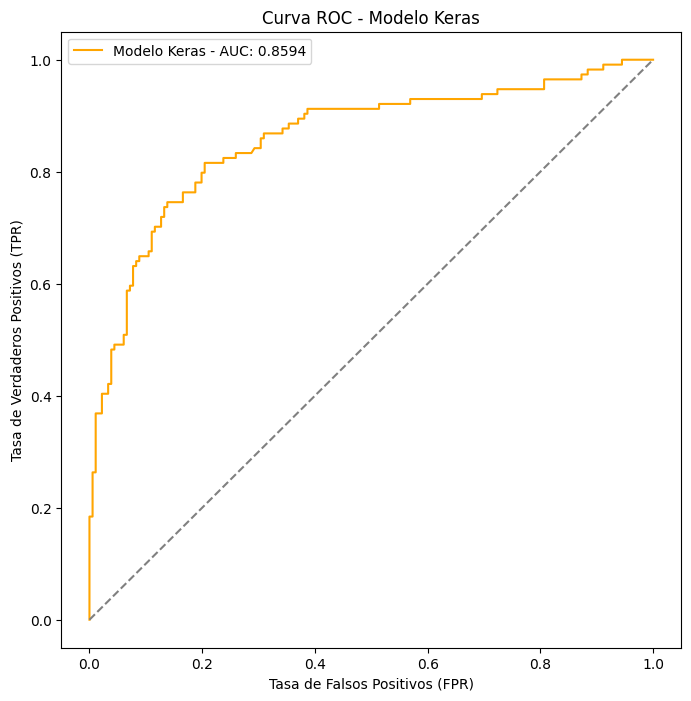

In [ ]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_keras)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Oranges')
plt.title('Matriz de Confusión - Modelo Keras')
plt.xlabel('Clase Predicha', fontsize=14)
plt.ylabel('Clase Real', fontsize=14)
plt.show()

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_proba_keras)
auc = roc_auc_score(y_test, y_proba_keras)
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='orange', label=f'Modelo Keras - AUC: {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curva ROC - Modelo Keras')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend()
plt.show()

Available metrics: dict_keys(['AUC', 'loss', 'val_AUC', 'val_loss'])


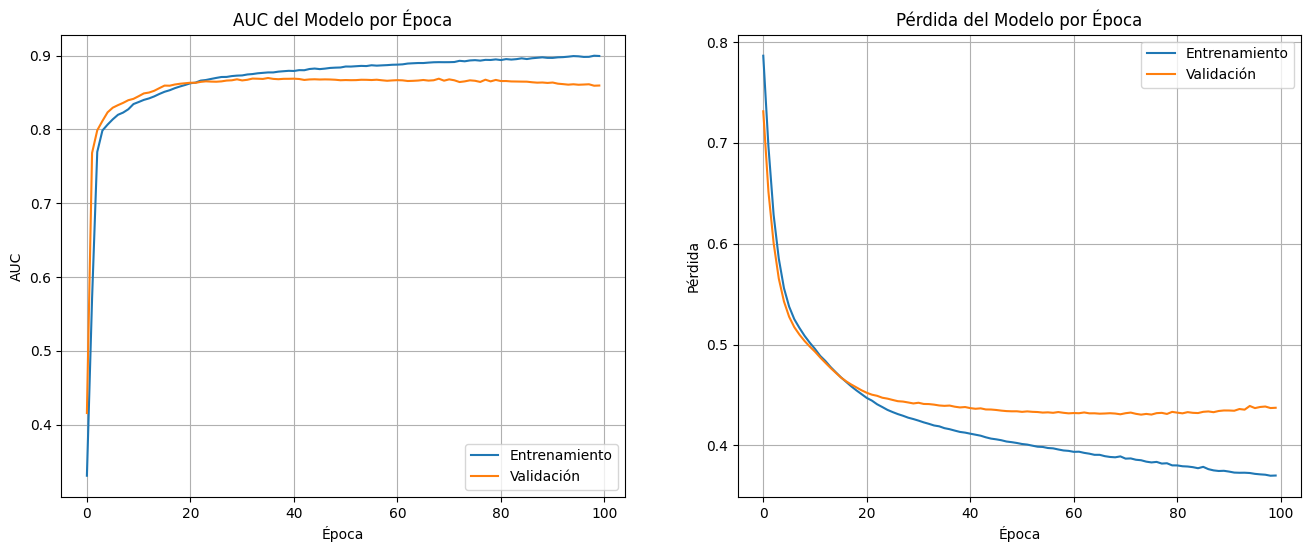

In [ ]:
# 1. See what keys are available in the history object
print("Available metrics:", history.history.keys())

# 2. Use the correct keys in your plotting code
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de AUC - **Use the correct key name you found above**
# For example, if the key is 'AUC' or 'auc_1'
ax1.plot(history.history['AUC'], label='Entrenamiento') # <-- FIX THIS LINE
ax1.plot(history.history['val_AUC'], label='Validación') # <-- AND THIS LINE
ax1.set_title('AUC del Modelo por Época')
ax1.set_ylabel('AUC')
ax1.set_xlabel('Época')
ax1.legend(loc='lower right')
ax1.grid(True)

# Gráfico de Pérdida (this part is usually correct)
ax2.plot(history.history['loss'], label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida del Modelo por Época')
ax2.set_ylabel('Pérdida')
ax2.set_xlabel('Época')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.show()

---
## 5. Conclusión y Comparación

En este notebook, hemos implementado tres versiones de un Perceptrón Multicapa para el mismo problema de clasificación. Cada enfoque tiene sus propias ventajas:

| Enfoque             | Ventajas                                                              | Desventajas                                                     |
|---------------------|-----------------------------------------------------------------------|-----------------------------------------------------------------|
| **Manual (NumPy)** | **Gran valor educativo**, control total sobre cada paso del algoritmo. | Propenso a errores, difícil de escalar, lento y poco optimizado.|
| **Scikit-learn** | **Fácil y rápido de usar**, bien integrado con otras herramientas de ML. | Menos flexible para arquitecturas de red personalizadas.       |
| **Keras/TensorFlow** | **Máxima flexibilidad**, estándar de la industria, optimizado para GPU. | Curva de aprendizaje más pronunciada, más verboso para modelos simples.|

Al comparar las métricas de rendimiento (Accuracy y AUC), generalmente se observa que las librerías especializadas como Scikit-learn y Keras superan a la implementación manual, ya que utilizan optimizadores más avanzados y técnicas de inicialización de pesos más robustas. Keras, además, proporciona herramientas excelentes para monitorear el entrenamiento, lo que ayuda a diagnosticar problemas como el sobreajuste (*overfitting*).